# PCA for Dimensionality Reduction

This project demonstrates Principal Component Analysis (PCA) for reducing the dimensionality of the Breast Cancer Wisconsin dataset.

The project investigates how PCA can reduce the number of features while preserving most of the information in the dataset. Logistic Regression is used to compare model performance before and after dimensionality reduction.

## Objective

The objective of this project is to understand and implement PCA to reduce the dimensionality of a dataset while retaining maximum variance

We will compare the performance of Logistic Regression before and after applying PCA

## 1. Importing Required Libraries

In this project, we wil use Numpy, Pandas, Matplotlib, Scikit-learn and other required libraries for data preprocessing, PCA and model evaluation.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score



## 2. Loading the Dataset

The Breast Cancer Wisconsin dataset is loaded using Scikit-learn.

The dataset contains 569 samples and 30 numerical features along with a target variable.

In [ ]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns = data.feature_names)
df["target"] = data.target

df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 3. Understanding the Dataset

Before applying PCA, we inspect the dataset to understand its shape, data types, missing values, target distribution and statistical properties.

In [ ]:
df.shape

(569, 31)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [ ]:
df["target"].value_counts()

,count
target,
1,357
0,212


In [ ]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')

In [ ]:
df.dtypes.value_counts()

,count
float64,30
int64,1


In [ ]:
df.corr()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
mean radius,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066,-0.730029
mean texture,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205,-0.415185
mean perimeter,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019,-0.742636
mean area,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738,-0.708984
mean smoothness,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316,-0.358560
mean compactness,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,...,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382,-0.596534
mean concavity,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930,-0.696360
mean concave points,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661,-0.776614
mean symmetry,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,...,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413,-0.330499
mean fractal dimension,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,...,-0.051269,-0.205151,-0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297,0.012838


In [ ]:
#Checking correlation of all the features with the target column
df.corr(numeric_only = True)["target"].sort_values()

,target
worst concave points,-0.793566
worst perimeter,-0.782914
mean concave points,-0.776614
worst radius,-0.776454
mean perimeter,-0.742636
worst area,-0.733825
mean radius,-0.730029
mean area,-0.708984
mean concavity,-0.696360
worst concavity,-0.659610


## 4. Exploratory Data Analysis

We visualize the target distribution and selected features to understand the data before applying dimensionality reduction.

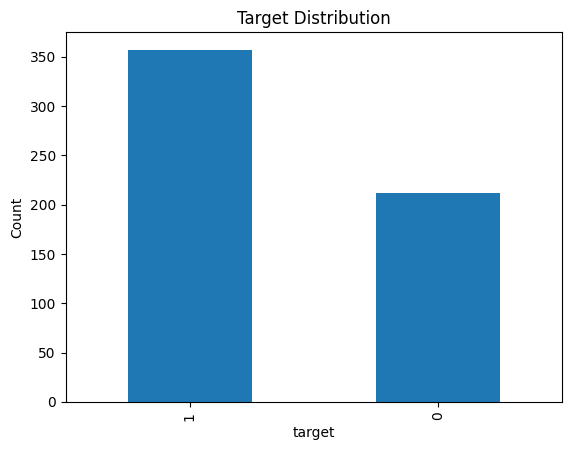

In [ ]:
# Plotting a bar graph to understand target distribution
df["target"].value_counts().plot(kind = "bar")
plt.xlabel("target")
plt.ylabel("Count")
plt.title("Target Distribution")
plt.show()

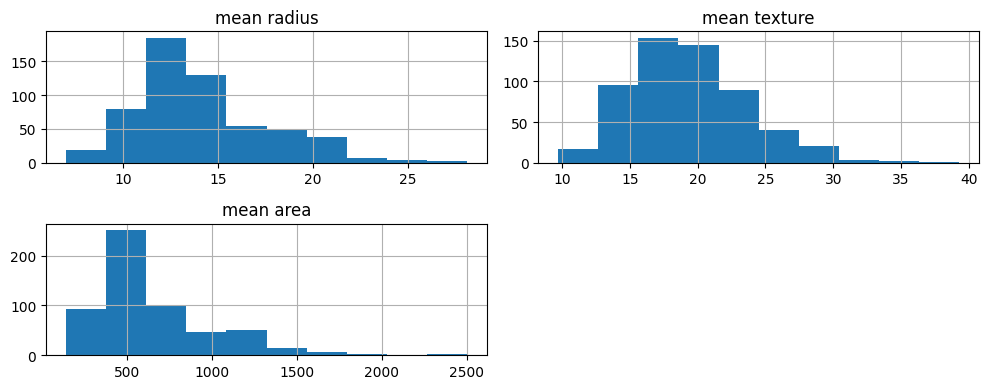

In [ ]:
#Checking how the data is spread around mean_radius, mean_texture, mean_area features.
df[["mean radius", "mean texture", "mean area"]].hist(figsize=(10, 4))
plt.tight_layout()
plt.show()

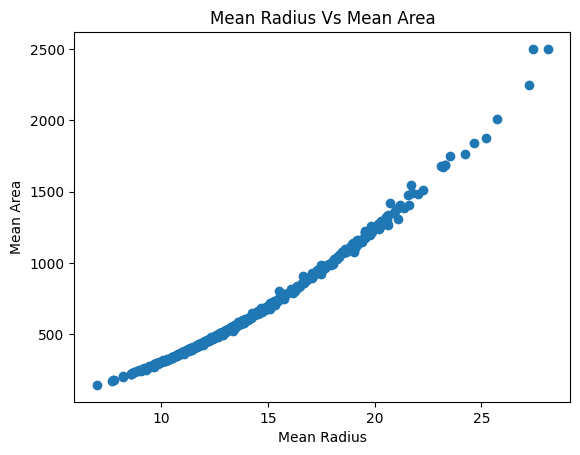

In [ ]:
# Plotting a scatter plot to visualize the relationship between mean radius and mean area
plt.scatter(x = df["mean radius"], y = df["mean area"])
plt.xlabel("Mean Radius")
plt.ylabel("Mean Area")
plt.title("Mean Radius Vs Mean Area")
plt.show()

In [ ]:
#Splitting the data into features and target column
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [ ]:
X.shape, y.shape

((569, 30), (569,))

## 5. Train-Test Split

The dataset is divided into training and testing sets.

We use stratified splitting to maintain a similar class distribution in both training and testing datasets.

In [ ]:
#Splitting the data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [ ]:
X_train.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
546,10.32,16.35,65.31,324.9,0.09434,0.04994,0.01012,0.005495,0.1885,0.06201,...,11.25,21.77,71.12,384.9,0.1285,0.08842,0.04384,0.02381,0.2681,0.07399
432,20.18,19.54,133.80,1250.0,0.11330,0.14890,0.21330,0.125900,0.1724,0.06053,...,22.03,25.07,146.00,1479.0,0.1665,0.29420,0.53080,0.21730,0.3032,0.08075
174,10.66,15.15,67.49,349.6,0.08792,0.04302,0.00000,0.000000,0.1928,0.05975,...,11.54,19.20,73.20,408.3,0.1076,0.06791,0.00000,0.00000,0.2710,0.06164
221,13.56,13.90,88.59,561.3,0.10510,0.11920,0.07860,0.044510,0.1962,0.06303,...,14.98,17.13,101.10,686.6,0.1376,0.26980,0.25770,0.09090,0.3065,0.08177
289,11.37,18.89,72.17,396.0,0.08713,0.05008,0.02399,0.021730,0.2013,0.05955,...,12.36,26.14,79.29,459.3,0.1118,0.09708,0.07529,0.06203,0.3267,0.06994


In [ ]:
y_train

,target
546,1
432,0
174,1
221,1
289,1
...,...
184,0
300,0
509,0
230,0


In [ ]:
X_train.shape, y_train.shape

((455, 30), (455,))

In [ ]:
X_test.shape, y_test.shape

((114, 30), (114,))

## 6. Feature Standardization

PCA is sensitive to the scale of features. Since the features in this dataset have different ranges, StandardScaler is used before applying PCA.

The scaler is fitted only on the training data to avoid data leakage.

In [ ]:
# Scaling the Features using StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled.shape

(455, 30)

In [ ]:
X_train_scaled.mean()

np.float64(-1.145197083276352e-16)

In [ ]:
X_train_scaled.std()

np.float64(1.0)

## 7. Applying PCA

Principal Component Analysis (PCA) is used to transform the original features into a smaller number of principal components.

Initially, PCA is applied without specifying the number of components to understand how much variance each component explains.

In [ ]:
pca = PCA()

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [ ]:
X_train_pca.shape

(455, 30)

## 8. Explained Variance

The explained variance ratio tells us how much of the total variance in the dataset is captured by each principal component.

Cumulative explained variance is used to determine the appropriate number of components.

In [ ]:
pca.explained_variance_ratio_

array([4.44134918e-01, 1.89446183e-01, 9.54335633e-02, 6.72468941e-02,
       5.51769040e-02, 3.93453424e-02, 2.18176591e-02, 1.58331722e-02,
       1.27878330e-02, 1.14544250e-02, 9.26269214e-03, 8.47428916e-03,
       7.99746679e-03, 5.30706257e-03, 3.12250212e-03, 2.57146110e-03,
       2.03925720e-03, 1.86696858e-03, 1.49100638e-03, 1.03671459e-03,
       9.25703045e-04, 8.66421035e-04, 7.19778970e-04, 5.88332657e-04,
       5.04652748e-04, 2.45507775e-04, 2.16103111e-04, 5.71732867e-05,
       2.57352579e-05, 4.27774949e-06])

In [ ]:
pca.explained_variance_ratio_.sum()

np.float64(1.0)

In [ ]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

cumulative_variance

array([0.44413492, 0.6335811 , 0.72901466, 0.79626156, 0.85143846,
       0.8907838 , 0.91260146, 0.92843464, 0.94122247, 0.95267689,
       0.96193959, 0.97041388, 0.97841134, 0.9837184 , 0.98684091,
       0.98941237, 0.99145162, 0.99331859, 0.9948096 , 0.99584631,
       0.99677202, 0.99763844, 0.99835822, 0.99894655, 0.9994512 ,
       0.99969671, 0.99991281, 0.99996999, 0.99999572, 1.        ])

In [ ]:
np.argmax(cumulative_variance >= 0.90) + 1

np.int64(7)

In [ ]:
np.argmax(cumulative_variance >= 0.95) + 1

np.int64(10)

## 9. Selecting the Number of Components

We choose the number of principal components required to retain approximately 95% of the total variance.

In this dataset, 10 principal components are sufficient to retain approximately 95% of the variance.

In [ ]:
pca_95 = PCA(n_components = 0.95)

X_train_pca = pca_95.fit_transform(X_train_scaled)
X_test_pca = pca_95.transform(X_test_scaled)

In [ ]:
X_train_pca.shape, X_test_pca.shape

((455, 10), (114, 10))

In [ ]:
pca_95.n_components_

np.int64(10)

In [ ]:
pca_95.explained_variance_ratio_.sum()

np.float64(0.9526768937417546)

## 10. PCA Visualization

The first two principal components are visualized to observe how the samples are distributed after dimensionality reduction.

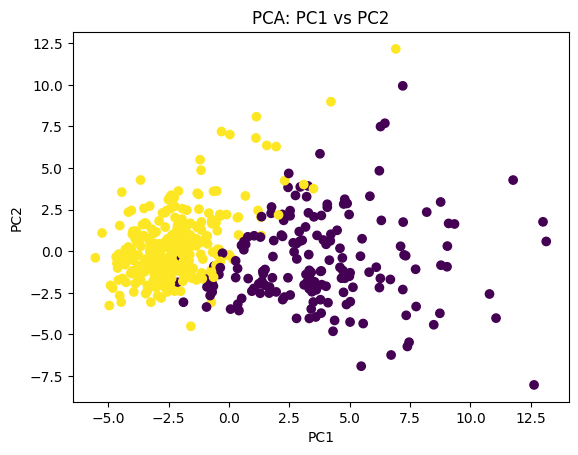

In [ ]:
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c = y_train)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA: PC1 vs PC2")
plt.show()

In [ ]:
pca_95.explained_variance_ratio_

array([0.44413492, 0.18944618, 0.09543356, 0.06724689, 0.0551769 ,
       0.03934534, 0.02181766, 0.01583317, 0.01278783, 0.01145443])

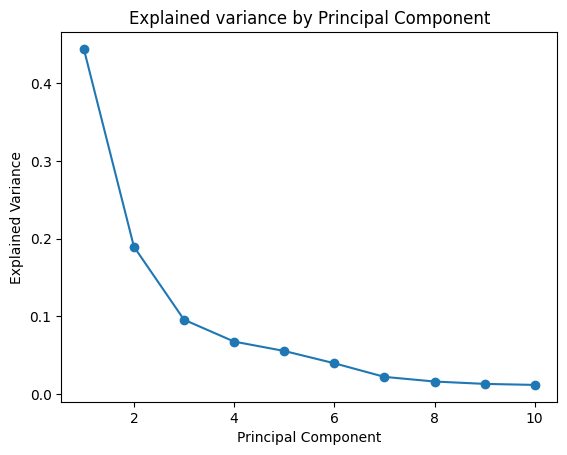

In [ ]:
plt.plot(range(1, len(pca_95.explained_variance_ratio_) + 1), pca_95.explained_variance_ratio_ , marker = "o")

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance")
plt.title("Explained variance by Principal Component")
plt.show()

## 11. Logistic Regression Before PCA

Logistic Regression is trained using the standardized original features to establish a baseline accuracy.

In [ ]:
original_model = LogisticRegression(max_iter = 1000)

original_model.fit(X_train_scaled, y_train)
original_y_pred = original_model.predict(X_test_scaled)

original_accuracy = accuracy_score(y_test, original_y_pred)
print("Accuracy without PCA:", original_accuracy)

Accuracy without PCA: 0.9824561403508771


## 12. Logistic Regression After PCA

Logistic Regression is trained using the PCA-transformed features.

The performance is then compared with the baseline model.

In [ ]:
pca_model = LogisticRegression(max_iter = 1000)

pca_model.fit(X_train_pca, y_train)
pca_y_pred = pca_model.predict(X_test_pca)

pca_accuracy = accuracy_score(y_test, pca_y_pred)
print("Accuracy with PCA:", pca_accuracy)

Accuracy with PCA: 0.9736842105263158


In [ ]:
original_dimensions = X_train.shape[1]
reduced_dimensions = X_train_pca.shape[1]

reduction_percentage = np.round(((original_dimensions - reduced_dimensions)/original_dimensions)*100, 2)

print("Original Dimensions", original_dimensions)
print("Reduced Dimensions", reduced_dimensions)
print("Reduction dimension percentage:", reduction_percentage,"%")

Original Dimensions 30
Reduced Dimensions 10
Reduction dimension percentage: 66.67 %


In [ ]:
accuracy_drop = original_accuracy - pca_accuracy

print("Accuracy drop:", accuracy_drop)

Accuracy drop: 0.00877192982456132


## 13. PCA Pipeline

A Scikit-learn Pipeline is created to combine standardization, PCA and Logistic Regression into a single workflow.

This makes the preprocessing and modeling process systematic and helps prevent data leakage when used correctly.

In [ ]:
pca_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components = 0.95)),
    ("clf", LogisticRegression(max_iter = 1000))
])

In [ ]:
pca_pipeline.fit(X_train, y_train)

pipeline_pred = pca_pipeline.predict(X_test)
pipeline_accuracy = accuracy_score(y_test, pipeline_pred)

print("Pipeline Accuracy:", pipeline_accuracy)

Pipeline Accuracy: 0.9736842105263158


## 14. Cross-Validation

5-fold cross-validation is performed to evaluate whether the model's performance is consistent across different splits of the dataset.

In [ ]:
cv_scores = cross_val_score(pca_pipeline, X, y, scoring = "accuracy", cv = 5)

print("CV scores:", cv_scores)
print("Mean CV accuracy:", np.mean(cv_scores))
print("Standard Deviation:", np.std(cv_scores))

CV scores: [0.99122807 0.97368421 0.98245614 0.97368421 0.98230088]
Mean CV accuracy: 0.98067070330694
Standard Deviation: 0.00655630132909533


## 15. Results

PCA reduced the number of features from 30 to 10 while retaining approximately 95% of the variance.

In [ ]:
results = pd.DataFrame({
    "Approach" : ["Logistic Regression without PCA", "Logistic Regression with PCA", "5-Fold Cross Validation"],
    "Accuracy" : [original_accuracy, pca_accuracy, np.mean(cv_scores)]
}, index =[1,2,3])

results

,Approach,Accuracy
1,Logistic Regression without PCA,0.982456
2,Logistic Regression with PCA,0.973684
3,5-Fold Cross Validation,0.980671


## Key Results

| Metric | Result |
|---|---:|
| Original Features | 30 |
| PCA Components | 10 |
| Dimensionality Reduction | 66.67% |
| Variance Retained | ~95% |
| Accuracy Without PCA | 98% |
| Accuracy With PCA | 97% |
| Mean 5-Fold CV Accuracy | ~98% |

## 16. Conclusion

PCA successfully reduced the dimensionality of the dataset from 30 features to 10 principal components, resulting in a 66.67% reduction in dimensionality while retaining approximately 95% of the variance.

The Logistic Regression accuracy decreased slightly from 98% to 97% after PCA. However, the significant reduction in dimensionality with only a small decrease in accuracy demonstrates that PCA can be useful for dimensionality reduction.

5-fold cross-validation produced a mean accuracy of approximately 98%, indicating consistent model performance.